<a href="https://colab.research.google.com/github/swamyaswagat/leo-mec-handover-aware-optimization/blob/main/01_orbit_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q skyfield sgp4 matplotlib numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.2 MB/s eta 0:00:00


In [ ]:
from skyfield.api import load, Topos
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from skyfield.api import Topos
import numpy as np

ground = Topos(
"22.3149 N",
"87.3105 E"
)

times = ts.utc(
2026,
6,
24,
13,
0,
range(1800)   # 30 min
)

best_sat = None
best_peak = -999

for s in satellites[:300]:

    diff = s - ground

    topo = diff.at(times)

    alt = topo.altaz()[0]

    peak = alt.degrees.max()

    if peak > best_peak:

        best_peak = peak

        best_sat = s

print("Best peak elevation:", best_peak)
print("Satellite:", best_sat.name)

Best peak elevation: 58.08625980891461
Satellite: STARLINK-1012


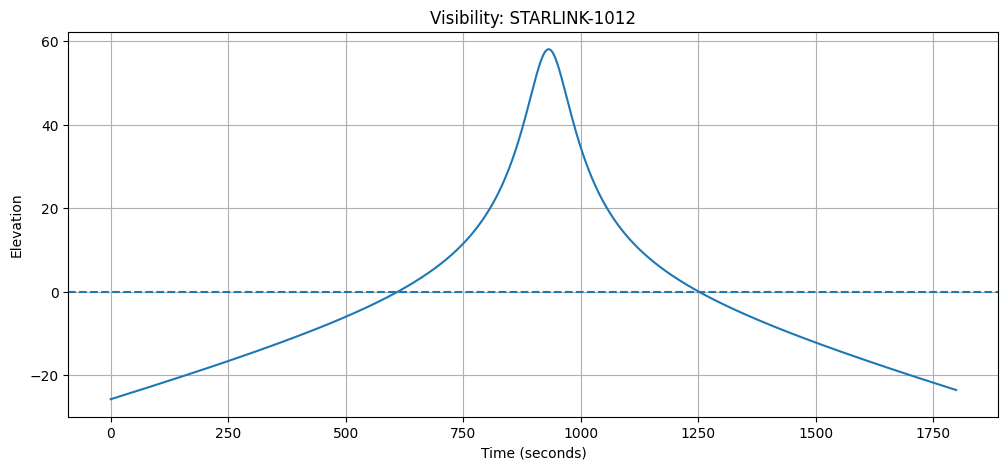

In [ ]:
sat = best_sat

difference = sat - ground

topo = difference.at(times)

alt, az, distance = topo.altaz()

plt.figure(figsize=(12,5))

plt.plot(
range(1800),
alt.degrees
)

plt.axhline(
0,
linestyle="--"
)

plt.xlabel("Time (seconds)")

plt.ylabel("Elevation")

plt.title(
f"Visibility: {sat.name}"
)

plt.grid()

plt.show()

In [ ]:
visible = alt.degrees > 0

indices = np.where(
visible
)[0]

if len(indices):

    rvt = indices[-1]

else:

    rvt = 0

print(
"RVT =",
rvt,
"seconds"
)

RVT = 1251 seconds


In [ ]:
plt.savefig(
    "figure1_visibility_curve.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved")

Saved


<Figure size 640x480 with 0 Axes>

In [ ]:
!ls

figure1_visibility_curve.png  gp.php  sample_data


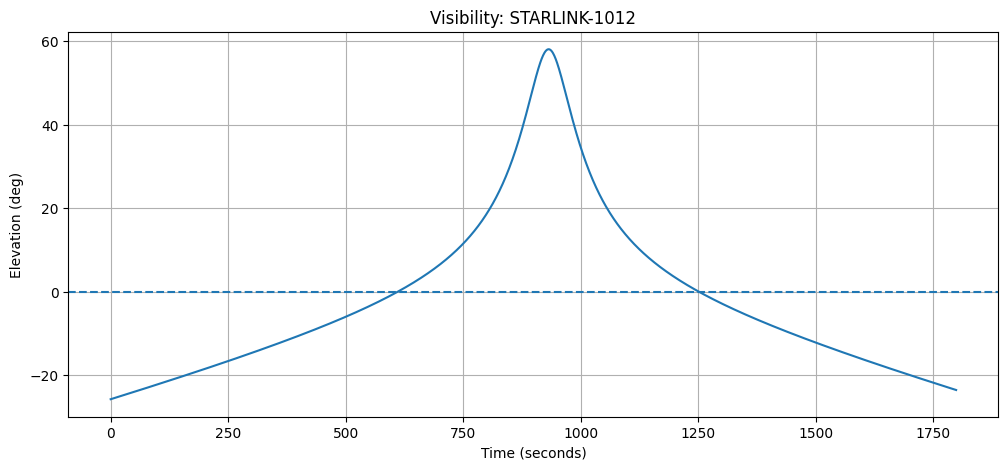

In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs(
    "figures",
    exist_ok=True
)

plt.figure(
    figsize=(12,5)
)

plt.plot(
    range(1800),
    alt.degrees
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Elevation (deg)"
)

plt.title(
    f"Visibility: {sat.name}"
)

plt.grid()

# SAVE FIRST
plt.savefig(
    "figures/figure1_visibility_curve.png",
    dpi=300,
    bbox_inches="tight"
)

# THEN SHOW
plt.show()

In [21]:
candidate_sats=[]

for s in satellites[:500]:

    diff=s-ground

    topo=diff.at(times)

    alt=topo.altaz()[0]

    peak=alt.degrees.max()

    if peak>0:

        candidate_sats.append(
            (
                s,
                peak
            )
        )

candidate_sats=sorted(
    candidate_sats,
    key=lambda x:x[1],
    reverse=True
)

selected=[
    x[0]
    for x in candidate_sats[:4]
]

print("Chosen Satellites")

for s in selected:

    print(s.name)

Chosen Satellites
STARLINK-1962
STARLINK-2478
STARLINK-1012
STARLINK-2417


In [22]:
import numpy as np

rvt_list=[]

for sat in selected:

    diff=sat-ground

    topo=diff.at(times)

    alt=topo.altaz()[0]

    visible=alt.degrees>0

    if visible.any():

        rvt=np.where(
            visible
        )[0][-1]

    else:

        rvt=0

    rvt_list.append(
        int(rvt)
    )

print("RVT Vector")

print(rvt_list)

RVT Vector
[1799, 641, 1251, 599]


In [23]:
rvt_norm=np.array(
    rvt_list
)/1800

print(
    "Normalized RVT"
)

print(
    rvt_norm
)

Normalized RVT
[0.99944444 0.35611111 0.695      0.33277778]


In [24]:
channel=np.random.uniform(
0.5,
1.0,
4
)

task_cpu=0.7

state=np.concatenate(
[
channel,
rvt_norm,
[
task_cpu
]
]
)

print(
"State Length:",
len(state)
)

print(
state
)

State Length: 9
[0.63952337 0.94778551 0.87698739 0.86531896 0.99944444 0.35611111
 0.695      0.33277778 0.7       ]


In [26]:
import os

os.makedirs(
    "results",
    exist_ok=True
)

os.makedirs(
    "figures",
    exist_ok=True
)

os.makedirs(
    "data",
    exist_ok=True
)

print("Folders created")

Folders created


In [28]:
import pandas as pd

df=pd.DataFrame({

"satellite":
[
s.name
for s in selected
],

"rvt_seconds":
rvt_list,

"rvt_norm":
rvt_norm

})

df.to_csv(
"results/rvt_dataset.csv",
index=False
)

print(
"Saved successfully"
)

df

Saved successfully


,satellite,rvt_seconds,rvt_norm
0,STARLINK-1962,1799,0.999444
1,STARLINK-2478,641,0.356111
2,STARLINK-1012,1251,0.695000
3,STARLINK-2417,599,0.332778


In [30]:
task_size_mb=300

bandwidth=20

compute_delay=5

task_time=(
task_size_mb
/
bandwidth
)+compute_delay

print(
"Task Time:",
task_time,
"seconds"
)

Task Time: 20.0 seconds


In [31]:
channel=state[:4]

baseline_choice=np.argmax(
channel
)

print(
"Baseline selected:"
)

print(
selected[
baseline_choice
].name
)

print(
"Channel:",
channel[
baseline_choice
])

Baseline selected:
STARLINK-2478
Channel: 0.947785506763905


In [34]:
baseline_rvt=rvt_list[
baseline_choice
]

success=(
baseline_rvt
>
task_time
)

print(
"Completion:",
success
)

Completion: True


In [35]:
task_size_mb=12000

task_time=(
task_size_mb
/
bandwidth
)+5

print(
task_time
)

605.0


In [36]:
score=[]

for i in range(4):

    s=(
        0.5*channel[i]
        +
        0.5*rvt_norm[i]
    )

    score.append(
        s
    )

enhanced_choice=np.argmax(
score
)

print(
selected[
enhanced_choice
].name
)

STARLINK-1962


In [37]:
enhanced_rvt=rvt_list[
enhanced_choice
]

success=(
enhanced_rvt
>
task_time
)

print(
"Enhanced Completion:",
success
)

Enhanced Completion: True


In [38]:
task_size_mb=16000

bandwidth=20

compute_delay=5

task_time=(
task_size_mb
/
bandwidth
)+compute_delay

print(
"Task Time:",
task_time
)

Task Time: 805.0


In [39]:
baseline_rvt=rvt_list[
baseline_choice
]

baseline_success=(
baseline_rvt
>
task_time
)

print(
"Baseline Satellite:",
selected[
baseline_choice
].name
)

print(
"Baseline RVT:",
baseline_rvt
)

print(
"Baseline Success:",
baseline_success
)

Baseline Satellite: STARLINK-2478
Baseline RVT: 641
Baseline Success: False


In [40]:
enhanced_rvt=rvt_list[
enhanced_choice
]

enhanced_success=(
enhanced_rvt
>
task_time
)

print(
"Enhanced Satellite:",
selected[
enhanced_choice
].name
)

print(
"Enhanced RVT:",
enhanced_rvt
)

print(
"Enhanced Success:",
enhanced_success
)

Enhanced Satellite: STARLINK-1962
Enhanced RVT: 1799
Enhanced Success: True


In [41]:
comparison=pd.DataFrame({

"Model":[
"Baseline",
"Enhanced"
],

"Satellite":[
selected[
baseline_choice
].name,

selected[
enhanced_choice
].name
],

"TaskTime":[
task_time,
task_time
],

"RVT":[
baseline_rvt,
enhanced_rvt
],

"Success":[
baseline_success,
enhanced_success
]

})

comparison

,Model,Satellite,TaskTime,RVT,Success
0,Baseline,STARLINK-2478,805.0,641,False
1,Enhanced,STARLINK-1962,805.0,1799,True


In [47]:
np.random.seed(42)

num_tasks=1000

task_sizes=np.random.randint(
500,
50000,
num_tasks
)

task_times=(
task_sizes
/
20
)+5

print(
"Max Task Time:",
task_times.max()
)

Max Task Time: 2500.35


In [48]:
baseline_results=[]

enhanced_results=[]

for t in task_times:

    baseline_ok=(
        baseline_rvt
        >=
        t
    )

    enhanced_ok=(
        enhanced_rvt
        >=
        t
    )

    baseline_results.append(
        baseline_ok
    )

    enhanced_results.append(
        enhanced_ok
    )

baseline_rate=(
100*
np.mean(
baseline_results
)
)

enhanced_rate=(
100*
np.mean(
enhanced_results
)
)

print(
"Baseline:",
round(
baseline_rate,
2
),
"%"
)

print(
"Enhanced:",
round(
enhanced_rate,
2
),
"%"
)

Baseline: 26.9 %
Enhanced: 71.1 %


In [49]:
gain=(
enhanced_rate
-
baseline_rate
)

print(
"Absolute Improvement:",
round(
gain,
2
),
"%"
)

Absolute Improvement: 44.2 %


In [50]:
summary2=pd.DataFrame({

"Metric":[
"Completion"
],

"Baseline":[
baseline_rate
],

"Enhanced":[
enhanced_rate
],

"Gain":[
gain
]

})

summary2

,Metric,Baseline,Enhanced,Gain
0,Completion,26.9,71.1,44.2


In [51]:
summary2.to_csv(
"results/stress_test.csv",
index=False
)

In [52]:
np.random.seed(42)

T=500

arrival=np.random.poisson(
5,
T
)

service=4

print(
arrival[:10]
)

[5 4 4 5 5 3 5 4 6 7]


In [53]:
queue_base=[]

q=0

for a in arrival:

    q=max(
        q-service,
        0
    )+a

    queue_base.append(
        q
    )

In [54]:
queue_lyap=[]

q=0

V=5

for a in arrival:

    dynamic_service=service

    if q>20:

        dynamic_service+=2

    q=max(
        q-dynamic_service,
        0
    )+a

    queue_lyap.append(
        q
    )

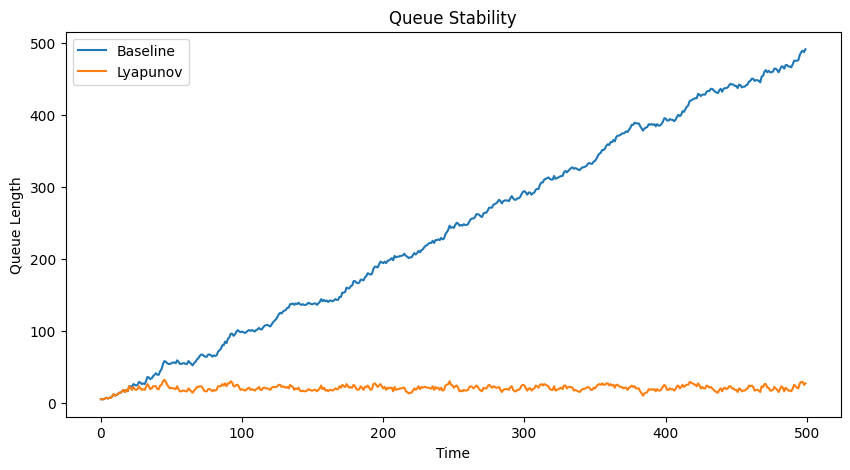

In [55]:
import matplotlib.pyplot as plt

plt.figure(
figsize=(10,5)
)

plt.plot(
queue_base,
label="Baseline"
)

plt.plot(
queue_lyap,
label="Lyapunov"
)

plt.xlabel(
"Time"
)

plt.ylabel(
"Queue Length"
)

plt.title(
"Queue Stability"
)

plt.legend()

plt.savefig(
"figures/queue_stability.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [56]:
base_peak=max(
queue_base
)

lyap_peak=max(
queue_lyap
)

print(
"Baseline Peak:",
base_peak
)

print(
"Lyapunov Peak:",
lyap_peak
)

Baseline Peak: 491
Lyapunov Peak: 32


In [61]:
queue_dpp=[]

energy=[]

q=0

V=2

for a in arrival:

    drift=q*q

    dynamic_service=int(

        min(
            10,

            max(
                4,

                np.sqrt(q)/2
                +
                V
            )
        )

    )

    q=max(
        q-dynamic_service,
        0
    )+a

    queue_dpp.append(
        q
    )

    energy.append(
        dynamic_service
    )

In [62]:
table2=pd.DataFrame({

"Method":[
"Baseline",
"Threshold",
"DPP_v2"
],

"PeakQueue":[
max(queue_base),
max(queue_lyap),
max(queue_dpp)
],

"Energy":[
base_energy,
lyap_energy,
sum(energy)
]

})

table2

,Method,PeakQueue,Energy
0,Baseline,491,2000
1,Threshold,32,2466
2,DPP_v2,67,2441


In [63]:
table2["Efficiency"]=(
table2["PeakQueue"]
*
table2["Energy"]
)

table2

,Method,PeakQueue,Energy,Efficiency
0,Baseline,491,2000,982000
1,Threshold,32,2466,78912
2,DPP_v2,67,2441,163547
